In [1]:
import os

import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats
from astropy.coordinates import SkyCoord
from astropy.io import fits
from gammapy.irf import load_irf_dict_from_file
from scipy.stats import chi2, poisson
from scipy.optimize import curve_fit

**Adjust with the correct file paths**

In [2]:
blazar_coord = SkyCoord.from_name("Mrk 501")
data_folder = "../cta_dc_data/mrk_501/"
irf_file = "../cta_dc_data/irfs/Prod5-North-40deg-AverageAz-4LSTs09MSTs.180000s-v0.1.fits.gz"

In [3]:
blazar_l = blazar_coord.galactic.l.deg
blazar_b = blazar_coord.galactic.b.deg

hbus = []
for filename in os.listdir(data_folder):
    hbus.append(fits.open(data_folder + filename))

irf = load_irf_dict_from_file(irf_file)
aeff = irf["aeff"]
print(f"Pointings: {len(hbus)}")

Pointings: 126


In [4]:
e_bins=np.logspace(np.log10(0.05), np.log10(50), 16)
e_mins=e_bins[:-1]
e_maxs=e_bins[1:]
e=np.sqrt(e_mins*e_maxs)
de=e_maxs-e_mins

th2_bins=np.linspace(0,0.16,17)
th2=(th2_bins[1:]+th2_bins[:-1])/2.

**Data collecting and overview**

In [5]:
bkg_subtraction_radius = 0.4

cts_s = np.zeros((len(e), len(th2)))
cts_b = np.zeros((len(e), len(th2)))

t_expo = 0

for hbu in hbus:
    data_raw = hbu["EVENTS"].data

    t = data_raw["TIME"]
    t = np.sort(t)
    t_expo += t[-1] - t[0]

    coord = SkyCoord(
        ra=data_raw["RA"] * u.deg, dec=data_raw["DEC"] * u.deg, frame="icrs"
    )

    pointing_coord = SkyCoord(
        ra=hbu[1].header["RA_PNT"] * u.deg,
        dec=hbu[1].header["DEC_PNT"] * u.deg,
        frame="icrs",
    )

    bkg_center = SkyCoord(
        l=2 * pointing_coord.galactic.l - blazar_coord.galactic.l,
        b=2 * pointing_coord.galactic.b - blazar_coord.galactic.b,
        frame="galactic",
    )
    
    seps = coord.separation(blazar_coord).degree
    seps_b = coord.separation(bkg_center).degree
    src_pos_mask = seps < bkg_subtraction_radius
    bkg_pos_mask = seps_b < bkg_subtraction_radius

    energ = data_raw["ENERGY_TRUE"]

    for i, (energ_min, energ_max) in enumerate(zip(e_mins, e_maxs)):
        m_s = (energ>energ_min) & (energ<energ_max) & src_pos_mask
        m_b = (energ>energ_min) & (energ<energ_max )& bkg_pos_mask

        h_s, _ = np.histogram(seps[m_s]**2, bins=th2_bins)
        h_b, _ = np.histogram(seps_b[m_b]**2, bins=th2_bins)
        
        cts_s[i] += h_s
        cts_b[i] += h_b

print(f"Exposure time = {t_expo/60/60:.1f}h")

Exposure time = 17.8h


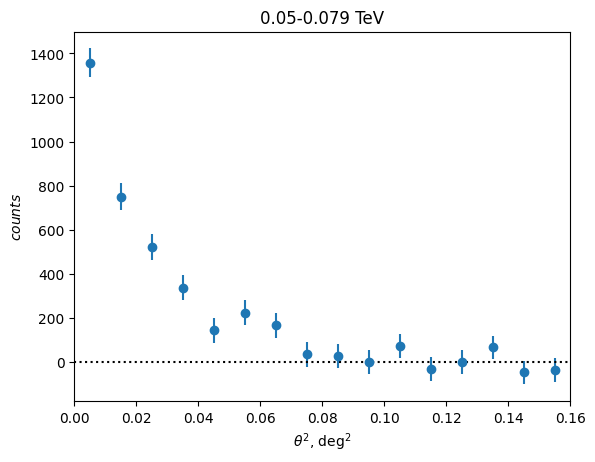

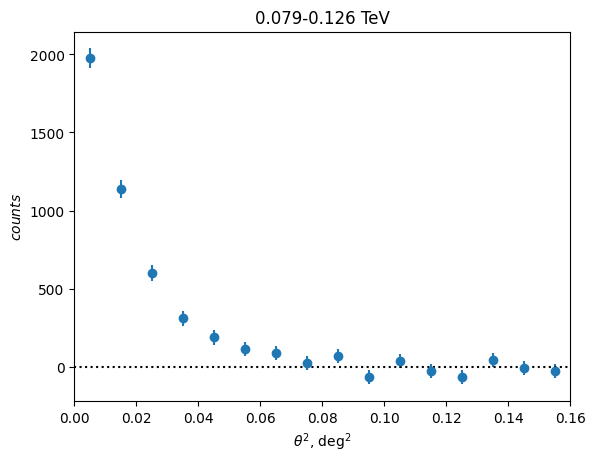

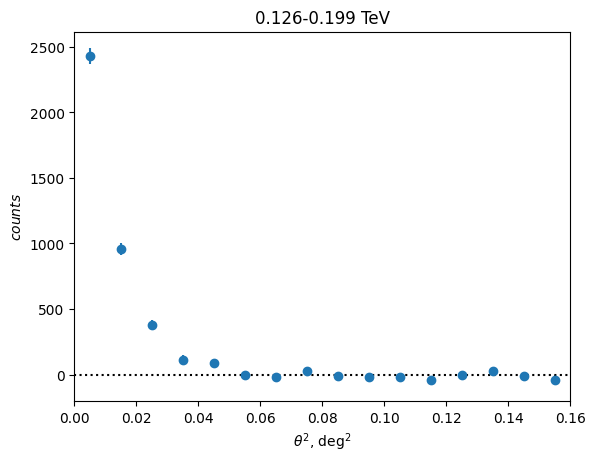

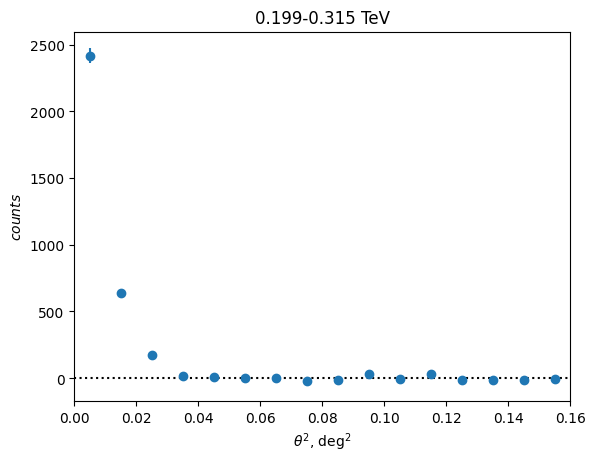

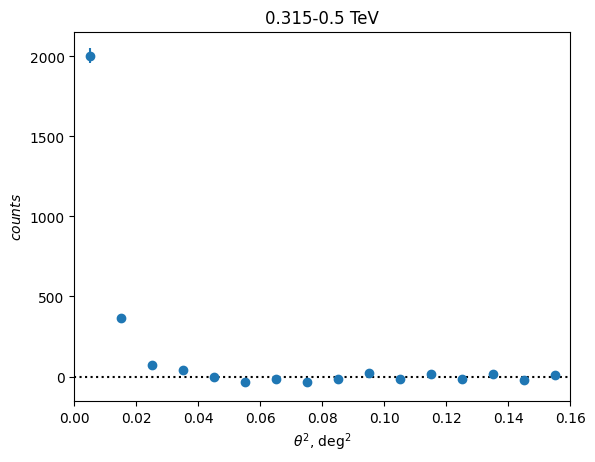

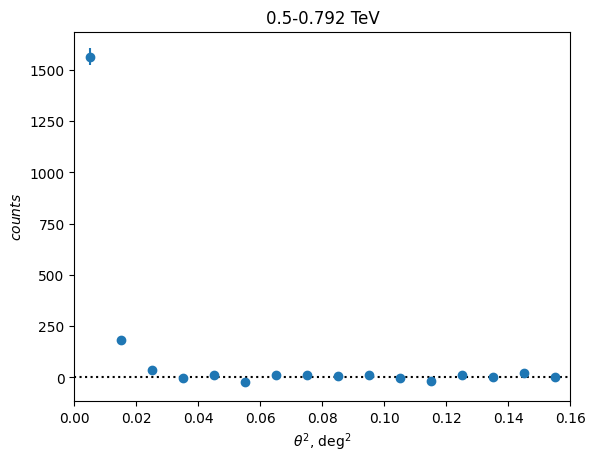

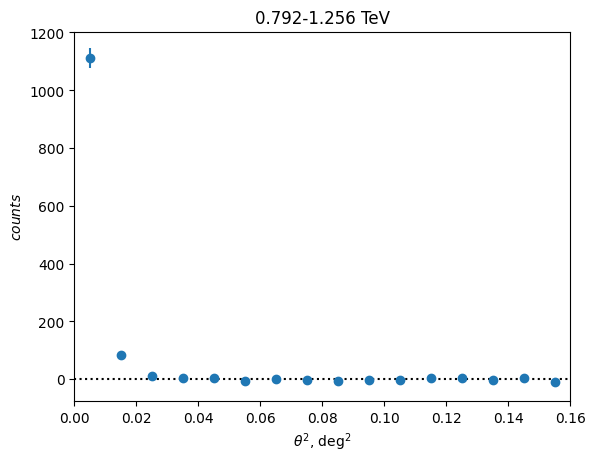

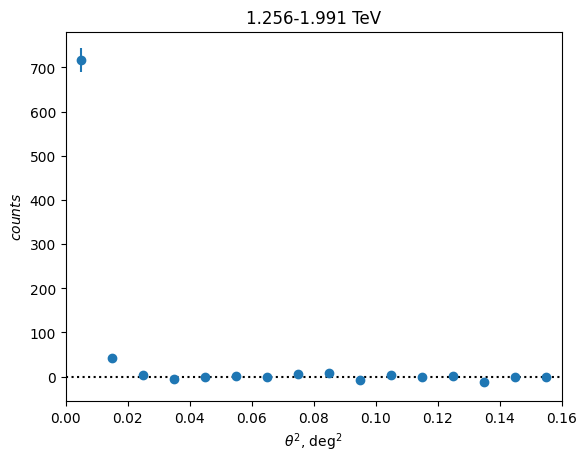

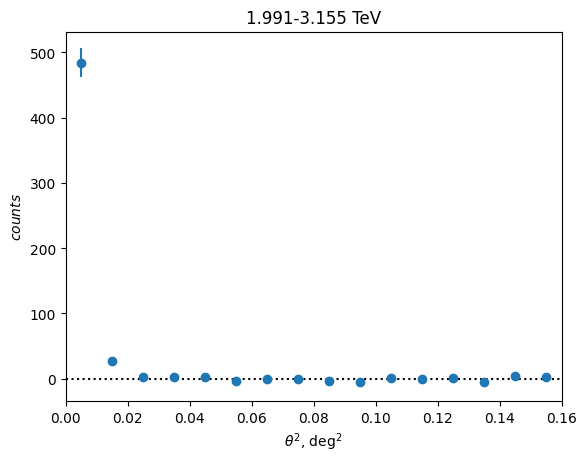

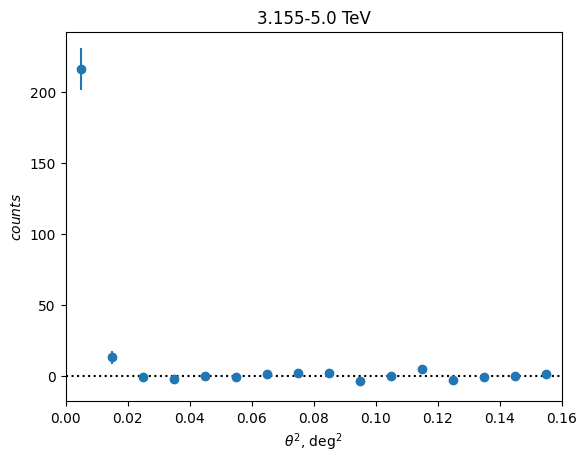

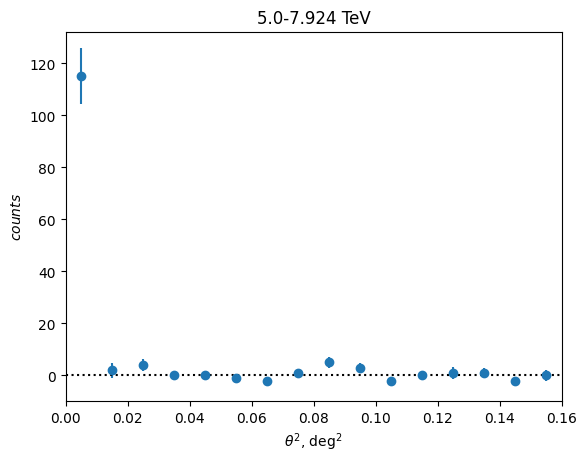

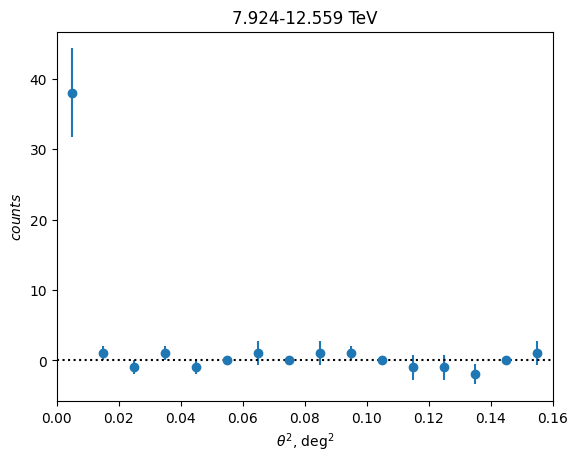

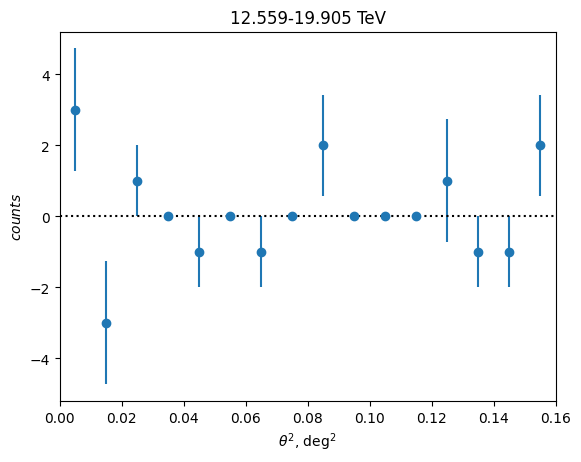

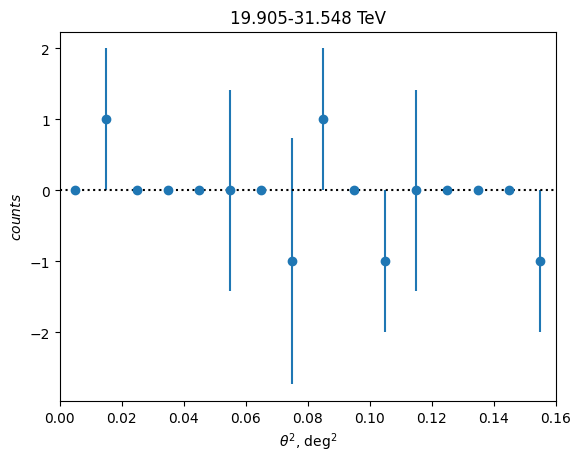

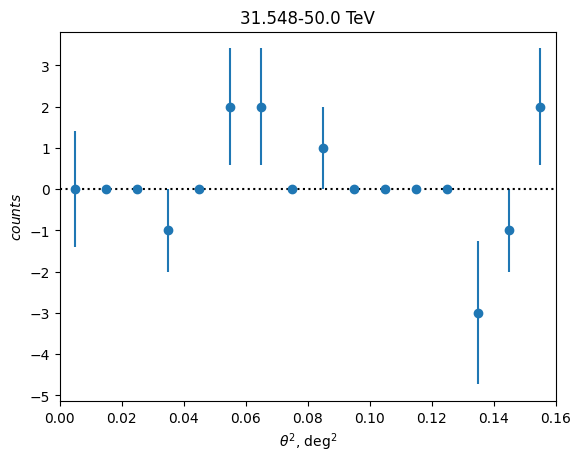

In [6]:
cts = cts_s - cts_b
cts_err = np.sqrt(cts_s + cts_b)

for i in range(cts.shape[0]):
    plt.figure()
    plt.errorbar(th2,cts[i], cts_err[i],fmt='o')
    plt.axhline(0,color='black',linestyle='dotted')
    plt.xlim(0,0.16)
    plt.title(str(round(e_mins[i],3))+'-'+str(round(e_maxs[i],3))+' TeV')
    plt.xlabel(r'$\theta^2$, deg$^2$')
    plt.ylabel(r'$counts$')
    plt.show()

In [7]:
def double_gaussian(th2, norm_tot, norm_t, sigma_c, sigma_t):
    gauss_c = norm_tot * np.exp(-th2 / (2 * sigma_c**2))
    gauss_t = norm_tot * norm_t * np.exp(-th2 / (2 * sigma_t**2))
    return gauss_c + gauss_t

def triple_gaussian(th2, norm_tot, norm_t, norm_e, sigma_c, sigma_t, sigma_e):
    gauss_c = norm_tot * np.exp(-th2 / (2 * sigma_c**2))
    gauss_t = norm_tot * norm_t * np.exp(-th2 / (2 * sigma_t**2))
    gauss_e = norm_e * np.exp(-th2 / (2 * sigma_e**2))
    return gauss_c + gauss_t + gauss_e

In [8]:
crab_fit = np.load("../crab_fit.npy", allow_pickle=True)
crab_fit

array([array([1.13703809e+04, 1.44538627e+00, 1.01756094e-01, 1.59478468e-01]),
       array([2.56317340e+04, 2.21995712e-01, 9.46964320e-02, 2.13379469e-01]),
       array([2.68497308e+04, 4.52616877e-01, 7.12111729e-02, 1.53825832e-01]),
       array([2.92885400e+04, 2.65118032e-01, 7.35247225e-02, 1.61277084e-01]),
       array([2.73486744e+04, 2.31936806e-01, 6.45556354e-02, 1.54521916e-01]),
       array([2.24094071e+04, 1.81766023e-01, 6.07450794e-02, 1.50705198e-01]),
       array([1.52639143e+04, 1.81338907e-01, 5.55216523e-02, 1.39313354e-01]),
       array([8.98607270e+03, 1.21996105e-01, 5.59152430e-02, 1.56266801e-01]),
       array([ 5.22149782e+03,  1.24035470e-01,  5.17270406e-02, -1.44570676e-01]),
       array([2.41720911e+03, 1.41307943e-01, 5.02921366e-02, 1.36851485e-01]),
       array([1.15944171e+03, 1.18224480e-01, 4.92799835e-02, 1.48552149e-01]),
       array([3.87875378e+02, 8.80486286e-02, 5.95990529e-02, 1.75033991e-01]),
       array([3.24143921e+02, 1.3374

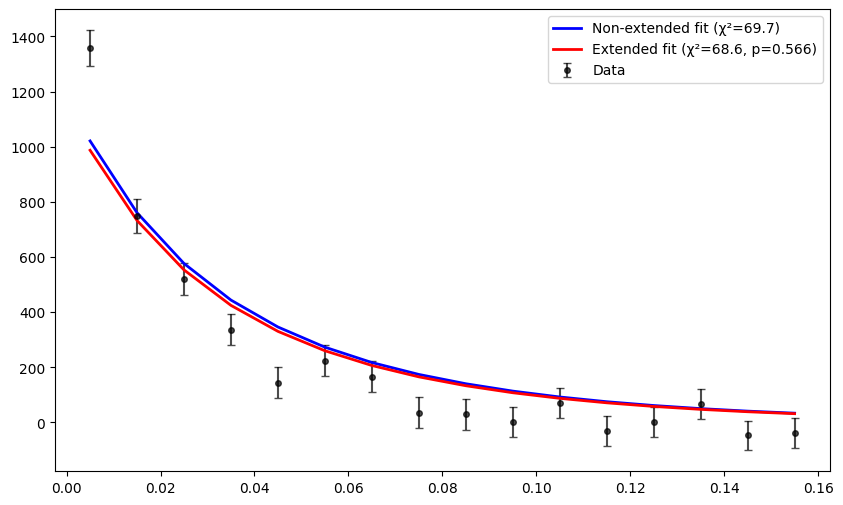

/tmp/ipykernel_1698/1723132227.py:25: OptimizeWarning: Covariance of the parameters could not be estimated
  popt_ext, pcov_ext = curve_fit(


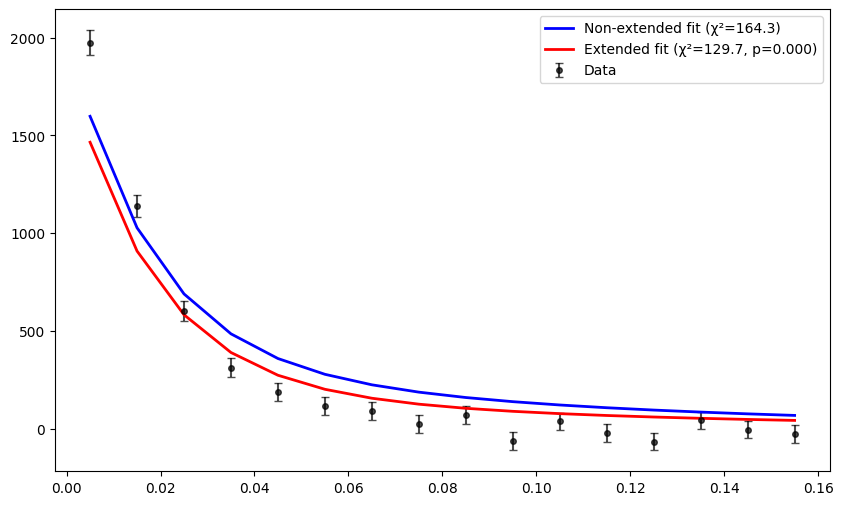

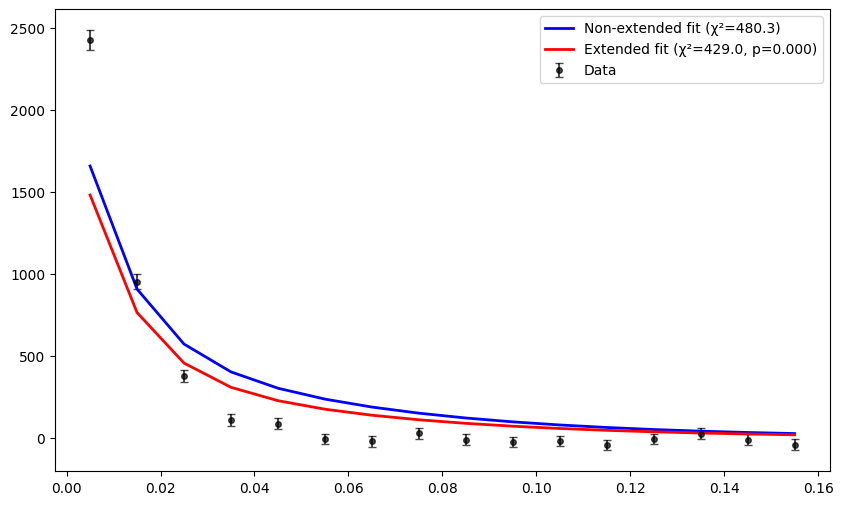

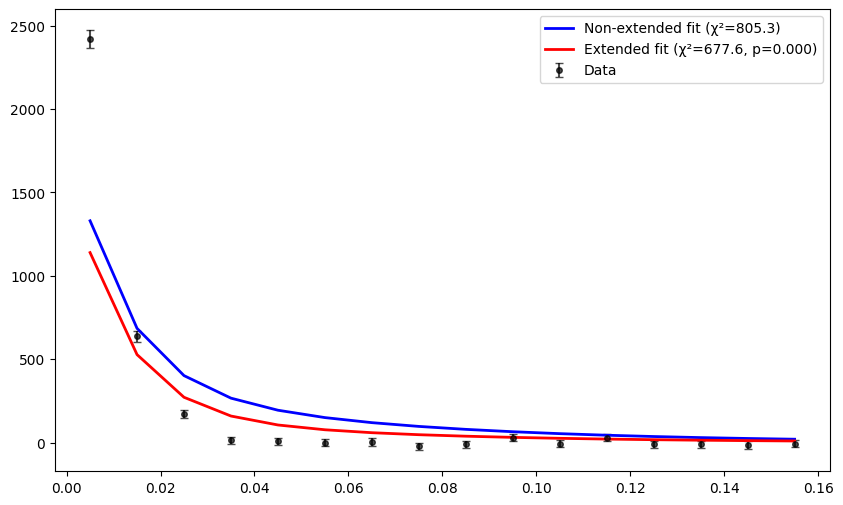

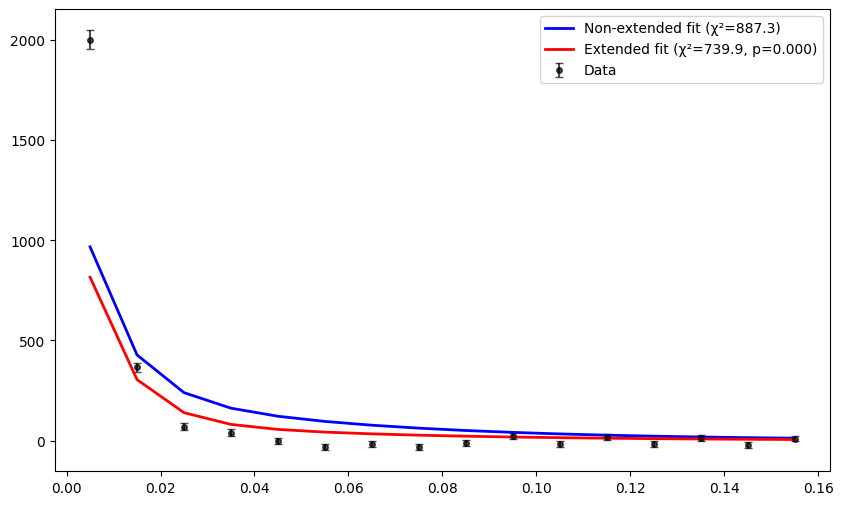

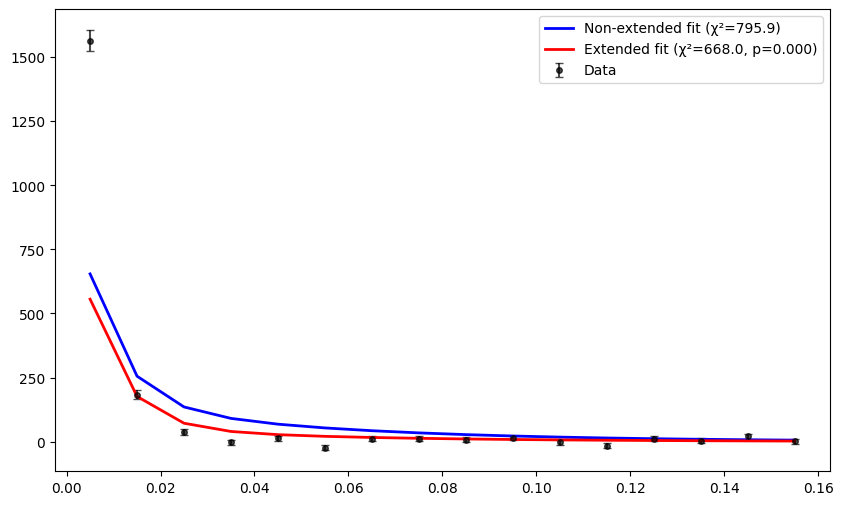

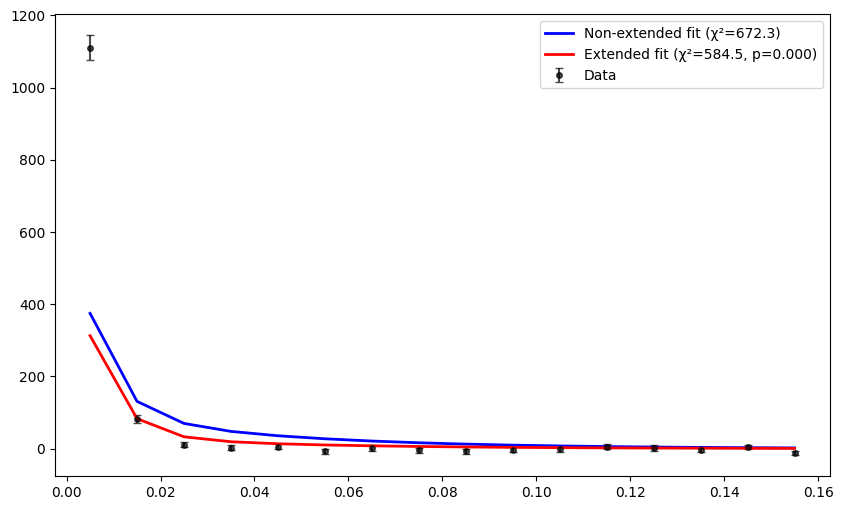

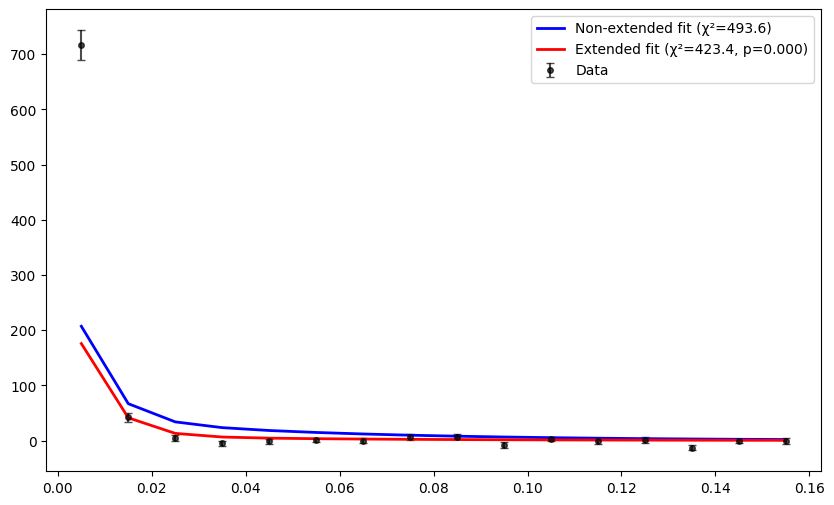

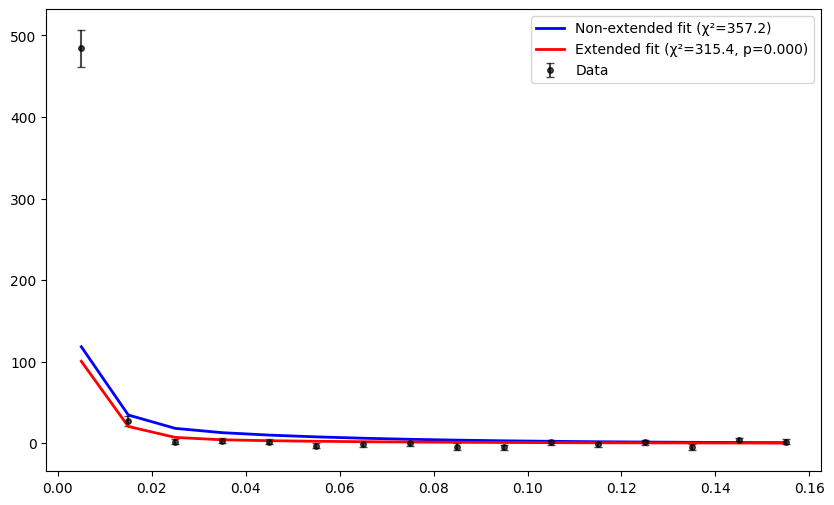

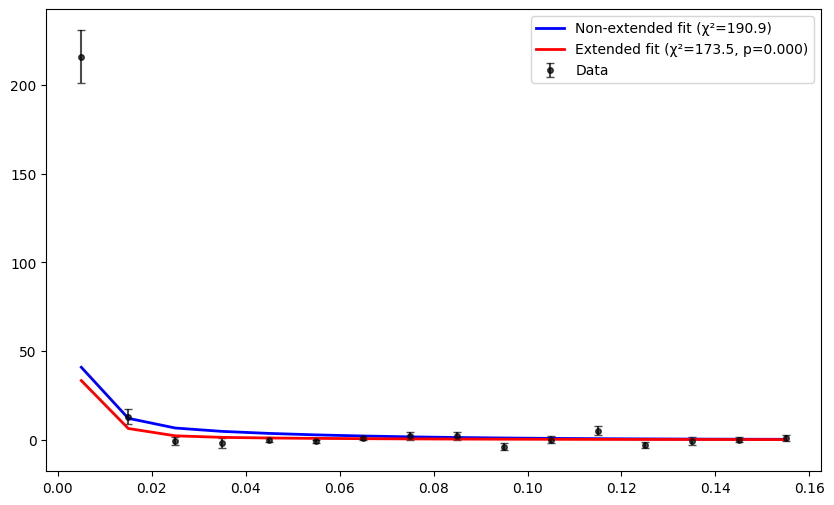

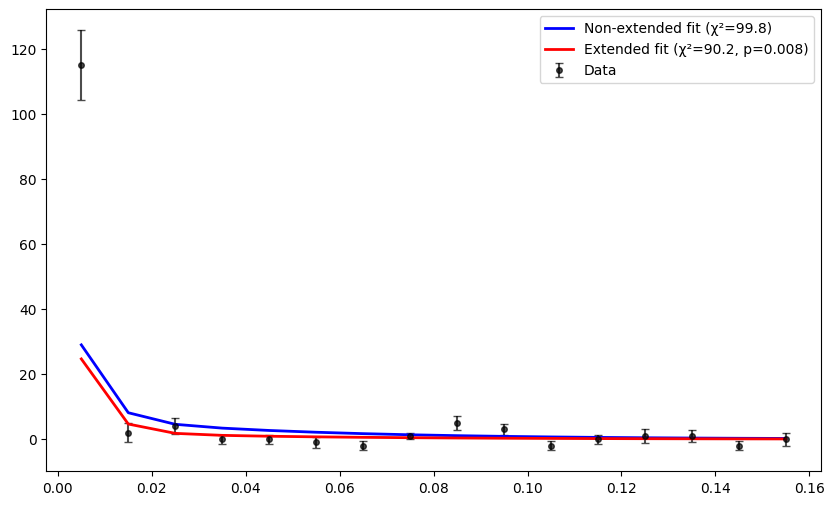

/tmp/ipykernel_1698/1723132227.py:12: OptimizeWarning: Covariance of the parameters could not be estimated
  popt_noext, pcov_noext = curve_fit(
/tmp/ipykernel_1698/1723132227.py:37: RuntimeWarning: divide by zero encountered in divide
  chi2_noext = np.sum(((ct - fit_noext) / ct_err) ** 2)
/tmp/ipykernel_1698/1723132227.py:38: RuntimeWarning: divide by zero encountered in divide
  chi2_ext = np.sum(((ct - fit_ext) / ct_err) ** 2)
/tmp/ipykernel_1698/1723132227.py:39: RuntimeWarning: invalid value encountered in scalar subtract
  delta_chi2 = chi2_noext - chi2_ext


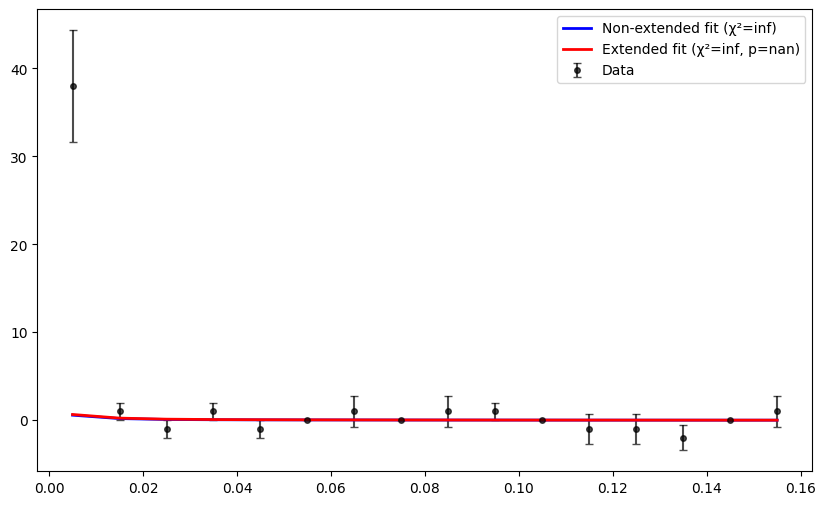

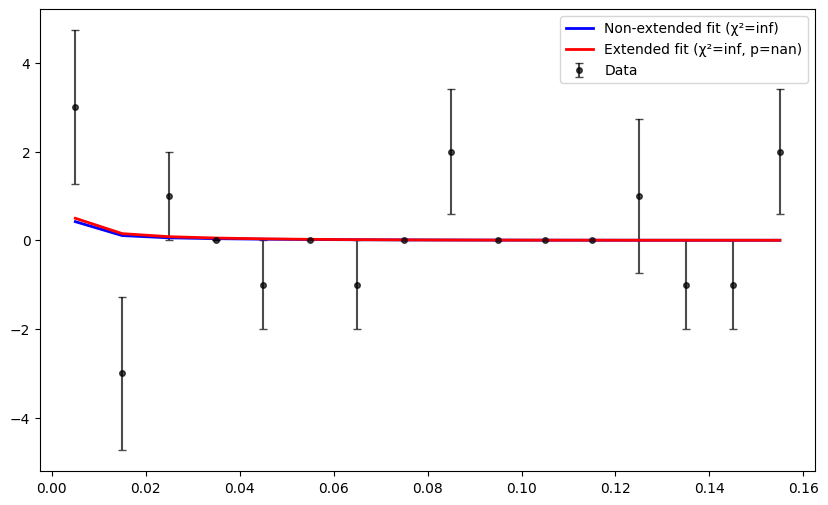

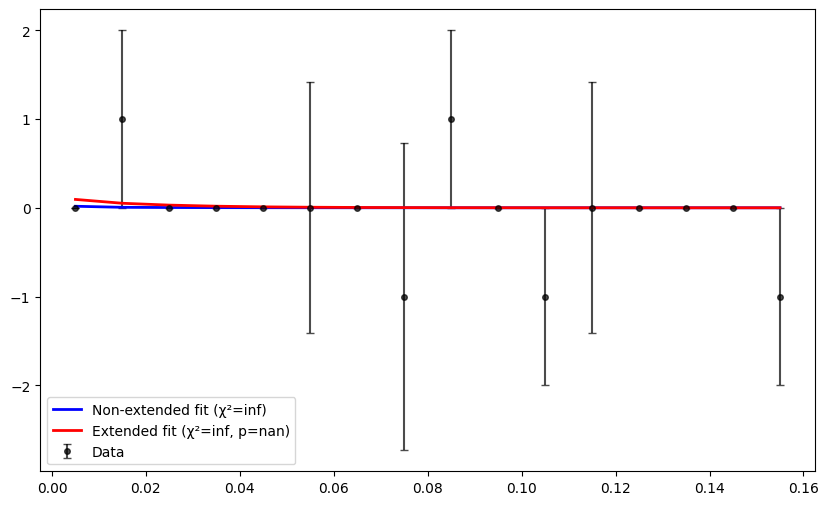

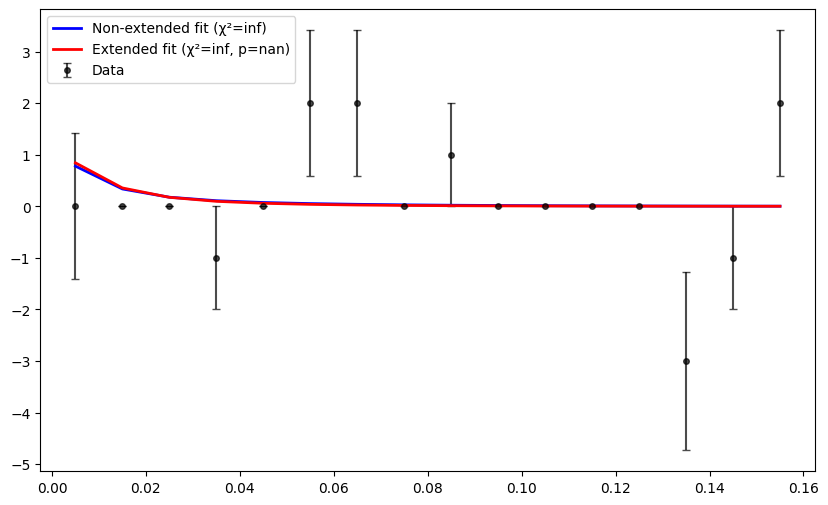

In [11]:
crab_fit = np.load("../crab_fit.npy", allow_pickle=True)

for i, (ct, ct_err) in enumerate(zip(cts, cts_err)):
    crab_fit_param = crab_fit[i]
    # change these
    init_guess_noext = [1.0]
    init_guess_ext = [0.1, 0.1]
    
    def non_ext_model(th2, norm_tot):
        return double_gaussian(th2, norm_tot, *crab_fit_param[1:])
        
    popt_noext, pcov_noext = curve_fit(
            non_ext_model,
            th2,
            ct,
            sigma=ct_err,
            p0=init_guess_noext,
            absolute_sigma=True,
            maxfev=10000,
        )
    
    def ext_model(th2, norm_e, sigma_e):
        return triple_gaussian(th2, popt_noext, norm_e, *crab_fit_param[1:], sigma_e)
        
    popt_ext, pcov_ext = curve_fit(
            ext_model,
            th2,
            ct,
            sigma=ct_err,
            p0=init_guess_ext,
            absolute_sigma=True,
            maxfev=10000,
        )
    fit_noext = non_ext_model(th2, *popt_noext)
    fit_ext = ext_model(th2, *popt_ext)
    delta_dof = 2 # here is 2 or 1?????
    chi2_noext = np.sum(((ct - fit_noext) / ct_err) ** 2)
    chi2_ext = np.sum(((ct - fit_ext) / ct_err) ** 2)
    delta_chi2 = chi2_noext - chi2_ext
    p_value = 1 - stats.chi2.cdf(delta_chi2, delta_dof)
    
    plt.figure(figsize=(10, 6))

    plt.errorbar(th2, ct, yerr=ct_err, fmt='o', 
                    markersize=4, capsize=3, capthick=1, 
                    label='Data', color='black', alpha=0.7)
        
    plt.plot(th2, fit_noext, 'b-', linewidth=2, 
                label=f'Non-extended fit (χ²={chi2_noext:.1f})')
        
    plt.plot(th2, fit_ext, 'r-', linewidth=2, 
                label=f'Extended fit (χ²={chi2_ext:.1f}, p={p_value:.3f})')
    plt.legend()
    plt.show()